In [1]:
%matplotlib inline

import phoebe
from phoebe.features import DatasetFeature
from phoebe.parameters import FloatParameter, ParameterSet, constraint
from astropy import units as u
import numpy as np

phoebe.logger()
b = phoebe.default_binary()
b.add_dataset('lc', compute_phases=phoebe.linspace(0,1,101))
b.set_value('irrad_method', 'none')
b.set_value_all('distortion_method', 'sphere')
b.run_compute(model='no_features')

class SinusoidalThirdLight(DatasetFeature):
    allowed_dataset_kinds = ['lc']

    @classmethod
    def create_feature_parameters(self, feature, **kwargs):
        params = []
        params += [FloatParameter(qualifier='amplitude',
                                  latexfmt=r'A_\mathrm{{ {feature} }}',
                                  value=kwargs.get('amplitude', 1.0),
                                  default_unit=u.W/u.m**2,
                                  description='Amplitude of the third light sinusoidal contribution')]
        params += [FloatParameter(qualifier='period',
                                  latexfmt=r'P_\mathrm{{ {feature} }}',
                                  value=kwargs.get('period', 1.0),
                                  default_unit=u.d,
                                  description='Period of the third light sinusoidal contribution')]
        params += [FloatParameter(qualifier='freq',
                                  latexfmt=r'f_\mathrm{{ {feature} }}',
                                  value=kwargs.get('freq', 2*np.pi/3.0),
                                  default_unit=u.rad/u.d, advanced=True,
                                  description='Frequency of the third light sinusoidal contribution')]

        constraints = [(constraint.freq, feature, 'feature')]

        return ParameterSet(params), constraints

    @classmethod
    def parse_bundle(cls, b, feature_ps):
        t0 = b.get_value(qualifier='t0', context='system', unit='d')
        feature_dict = cls.parse_from_feature_ps(b, feature_ps,
                                                 [{'qualifier': 'period', 'unit': 'd'},
                                                  {'qualifier': 'amplitude', 'unit': 'W/m**2'}])
        return dict(t0=t0, **feature_dict)
    
    def modify_model(self, b, model_ps):
        from astropy import units as u
        import numpy as np
        _skip_filter_checks = {'check_default': False, 'check_visible': False}

        for flux_param in model_ps.filter(qualifier='fluxes', **_skip_filter_checks).tolist():
            times = model_ps.get_value(qualifier='times', dataset=flux_param.dataset, unit=u.d, **_skip_filter_checks)
            flux_param.set_value(flux_param.get_value() + self.kwargs['amplitude'] * np.sin(2 * np.pi * (times - self.kwargs['t0']) / self.kwargs['period']), ignore_readonly=True, **_skip_filter_checks)

b.add_feature(SinusoidalThirdLight, dataset='lc01', amplitude=0.5, feature='sin_l3')
b.run_compute(model='with_sin_l3')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 149.63it/s]
Mon, 06 Jul 2026 16:12 BUNDLE       WARNING None
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 148.95it/s]


<ParameterSet: 3 parameters | qualifiers: comments, fluxes, times>

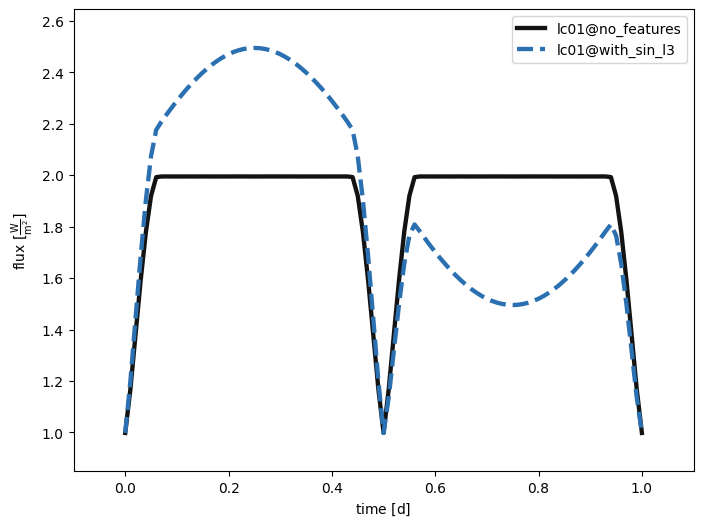

In [3]:
_ = b.plot(kind='lc', show=True, legend=True)